In [1]:
import seaborn as sns
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter

sns.set()


api = wandb.Api()

project = api.runs("naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation")#sapg_allegro_kuka_two_arms_reorientation
task_name = "AllegroKuka Two-Arm Reorientation"
metric = "successes/time"
metric_name = "Episode Successes"


print(len(project))    
task_runs = {
    "SAPG": [],
    "PPO": [],
    "PBT": [],
    "CPO2(wo/AdR)": [],
    #"CPO(w/AdR)": [],
}

# 各手法名がrun.tagに含まれているrunを抽出
for key in task_runs.keys():
    for run in project:
        if any(key in tag for tag in run.tags):
            task_runs[key].append(run)


print(task_runs)
for key in task_runs.keys():
    print(key,":", len(task_runs[key]))
    

65
{'SAPG': [<Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_24576envs_mixed_expl_learn_param_lf_1p_23_07_17h34m09s_seed4 (crashed)>, <Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_24576envs_mixed_expl_learn_param_lf_1p_21_07_16h53m46s_seed4 (crashed)>, <Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_24576envs_mixed_expl_learn_param_lf_1p_26_02_04h58m06s_seed3 (crashed)>, <Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_24576envs_mixed_expl_learn_param_lf_1p_26_02_04h58m06s_seed2 (crashed)>, <Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_24576envs_mixed_expl_learn_param_lf_1p_23_02_22h49m23s_seed3 (crashed)>, <Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_24576envs_mixed_expl_learn_param_lf_1p_23_02_22h49m22s_seed2 (crashed)>, <Run naoki-shitanda/sapg_allegro_kuka_two_arms_reorientation/uid_00_0210-SAPG_245

In [2]:
#print(task_runs["SAPG"][0].summary)

In [3]:
def calc_mean_std(runs, metric="rewards/step"):
    
    seed_dfs = []
    seeds = [run.config.get("seed", "not found") for run in runs]
    seed_set = set(seeds)
    
    # seedごとにデータを取得
    for seed in seed_set:
        print(seed, end=":")
        seed_runs = [run for run in runs if run.config.get("seed") == seed]
        seed_runs = sorted(seed_runs, key=lambda run: run.created_at) # 古い順に並べる
        dfs = []
        
        for i in range(len(seed_runs)):
            df = seed_runs[i].history(keys=[metric, "global_step"])
            df = df.set_index("global_step")
            df = df.dropna() # 欠損値を削除
            
            if i > 0:
                df = df.iloc[40:] # 先頭の行を削除
                # 前のrunの最後のglobal_stepより大きい値のみを保持
                if len(dfs) > 0:
                    last_step = dfs[-1].index.max()
                    df = df[df.index > last_step]
                
            dfs.append(df)
        
        # 連結前にインデックスが単調増加になるようにソート
        seed_df = pd.concat(dfs, axis=0)
        seed_df = seed_df.sort_index()  # global_stepでソート
        
        # 重複するインデックスを削除（最後のものを保持）
        seed_df = seed_df[~seed_df.index.duplicated(keep='last')]
        
        seed_df = seed_df.rename(columns={metric: f"seed{seed}"})    
        if "_step" in seed_df.columns:
            seed_df = seed_df.drop("_step", axis=1) # seed_dfから_stepを削除
    
        seed_dfs.append(seed_df)
        
    # 各seedのデータを連結して1つのデータフレームにする
    merged = pd.concat(seed_dfs, axis=1)
    
    # インデックスをソートして単調増加にする
    merged = merged.sort_index()
    
    # 内挿
    merged = merged.interpolate(method="linear", limit_direction="both")
    
    # 平均と標準偏差を計算
    mean = merged.mean(axis=1)
    std = merged.std(axis=1)
    
    return mean, std

# プロット
colours = {
    "SAPG": "green",
    "PPO": "blue",
    "PBT": "purple",
    "CPO2(wo/AdR)": "red",
    "CPO2(w/AdR)": "red"
}
styles = {
    "SAPG": (10, (5, 3, 1, 3, 1, 3)),
    "PPO": ":",
    "PBT": "-.",
    "CPO2(wo/AdR)": "-",
    "CPO2(w/AdR)": "-"
}




SAPG : 0:

1:2:3:4:(4661,) (4661,)

PPO : 0:1:2:3:4:(4673,) (4673,)

CPO2(wo/AdR) : 0:1:2:3:4:(2463,) (2463,)



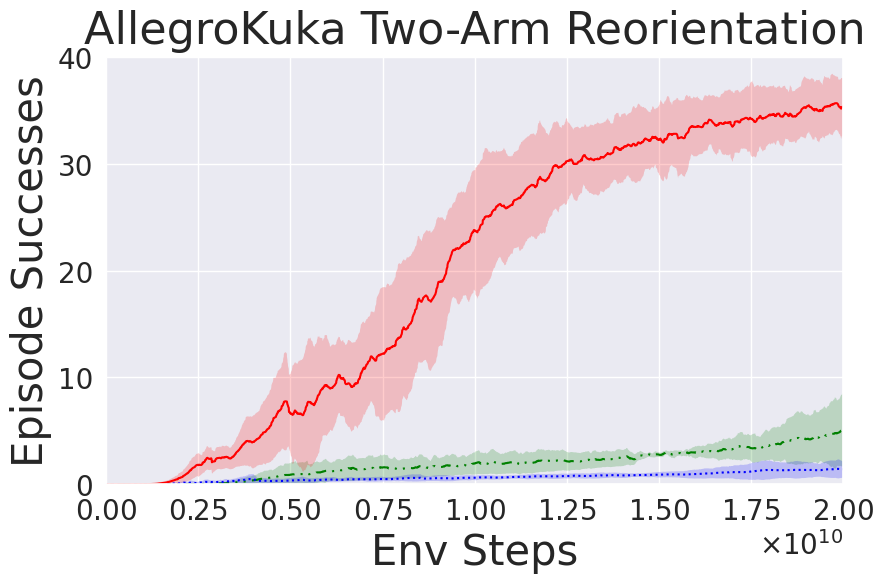

In [4]:
plt.figure(figsize=(9, 6))

for key in task_runs.keys():
    if len(task_runs[key]) == 0:
        continue
    print(key, ": ", end="")
    runs = task_runs[key]
    mean, std = calc_mean_std(runs, metric=metric)
    print(mean.shape, std.shape)
    plt.plot(mean.index, mean.values, label=key, color=colours[key], linestyle=styles[key])
    plt.fill_between(mean.index, mean - std, mean + std, alpha=0.2, color=colours[key], edgecolor="none")
    print("")

plt.xlabel("Env Steps", fontsize=30)
plt.ylabel(metric_name, fontsize=30)
plt.title(task_name, fontsize=32, pad=10)
plt.grid(True)
plt.xlim(0, 2e10)
#plt.ylim(0, 25) #40, 48, 25
if "Regrasping" in task_name:
    plt.ylim(0, 40)
elif "Reorientation" in task_name:
    plt.ylim(0, 48)
    if "Two" in task_name:
        plt.ylim(0, 40)
        
elif "Throw" in task_name:
    plt.ylim(0, 25)
else:
    print("Unknown task name")
plt.tight_layout(rect=[0, 0.07, 1, 1])


# 軸サイズ
plt.xticks()
plt.yticks()

ax = plt.gca()
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # 必ず指数表記を使う
ax.xaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(20)

plt.tick_params(axis='both', labelsize=20)  # 両軸の目盛を大きくする
plt.tight_layout()



plt.savefig("fig.svg")
